In [1]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.6 MB/s eta 0:00:00


In [2]:
# 📦 Imports and Setup
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, GRU, Dense, Dropout,
                                     Bidirectional, Conv1D, MaxPooling1D, Flatten, Input)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import gradio as gr

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 🧼 Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [5]:
df = pd.concat([
    pd.read_csv("/content/drive/MyDrive/Fake News /True.csv").assign(label=1),
    pd.read_csv("/content/drive/MyDrive/Fake News /Fake.csv").assign(label=0)
]).sample(frac=1, random_state=42).reset_index(drop=True)

In [6]:
df['title_clean'] = df['title'].apply(clean_text)

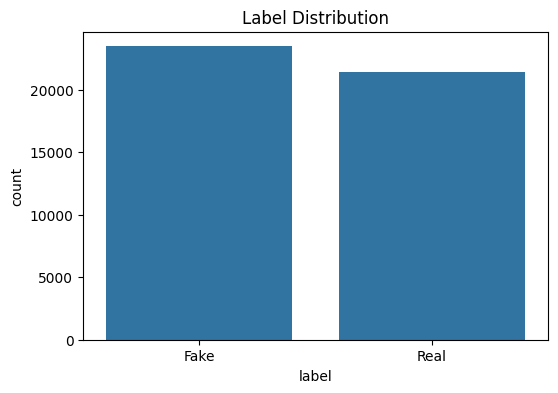

In [7]:
# 📊 EDA
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title("Label Distribution")
plt.xticks([0,1], ['Fake', 'Real'])
plt.show()

In [8]:
#Tokenization
max_words = 10000
max_len = 25
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['title_clean'])
X = tokenizer.texts_to_sequences(df['title_clean'])
X = pad_sequences(X, maxlen=max_len)
y = df['label'].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Define a function to build models for consistent settings
def build_compile_fit(model_fn, name):
    model = model_fn()
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    print(f"Training {name} model...")
    model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=6, batch_size=64)
    return model

In [11]:
# Model: BiLSTM
def bilstm_model_fn():
    return Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        Bidirectional(LSTM(64, return_sequences=False)),
         Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

In [12]:
# Model: CNN
def cnn_model_fn():
    return Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        Conv1D(128, 5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

In [13]:
# Model: GRU
def gru_model_fn():
    return Sequential([
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        GRU(64, return_sequences=False),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

In [14]:
bilstm_model = build_compile_fit(bilstm_model_fn, "BiLSTM")
cnn_model = build_compile_fit(cnn_model_fn, "CNN")
gru_model = build_compile_fit(gru_model_fn, "GRU")

Training BiLSTM model...
Epoch 1/6


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


562/562 ━━━━━━━━━━━━━━━━━━━━ 75s 125ms/step - accuracy: 0.8816 - loss: 0.2595 - val_accuracy: 0.9628 - val_loss: 0.1030
Epoch 2/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 62s 90ms/step - accuracy: 0.9786 - loss: 0.0634 - val_accuracy: 0.9606 - val_loss: 0.1116
Epoch 3/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 48s 85ms/step - accuracy: 0.9889 - loss: 0.0320 - val_accuracy: 0.9625 - val_loss: 0.1270
Epoch 4/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 90s 100ms/step - accuracy: 0.9955 - loss: 0.0144 - val_accuracy: 0.9626 - val_loss: 0.1371
Epoch 5/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 51s 91ms/step - accuracy: 0.9966 - loss: 0.0104 - val_accuracy: 0.9637 - val_loss: 0.1631
Epoch 6/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 53s 95ms/step - accuracy: 0.9976 - loss: 0.0063 - val_accuracy: 0.9646 - val_loss: 0.1975
Training CNN model...
Epoch 1/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.8753 - loss: 0.2962 - val_accuracy: 0.9571 - val_loss: 0.1114
Epoch 2/6
562/562 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9770 - loss: 0.0

In [15]:
# 📈 Evaluation (using best model)
def evaluate(model, name):
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    print(f"\n{name} Evaluation:\n", classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

BiLSTM Evaluation:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      4669
           1       0.96      0.96      0.96      4311

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980



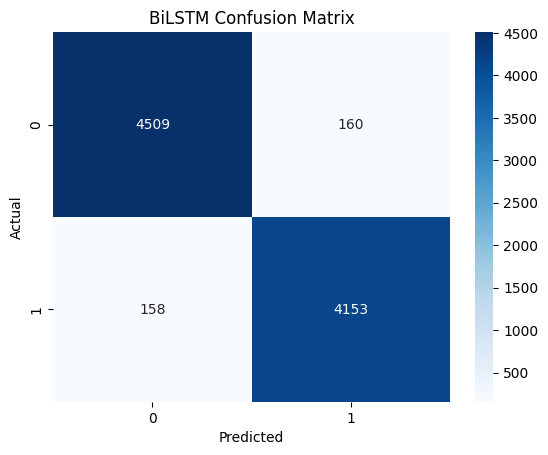

281/281 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

CNN Evaluation:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      4669
           1       0.96      0.96      0.96      4311

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980



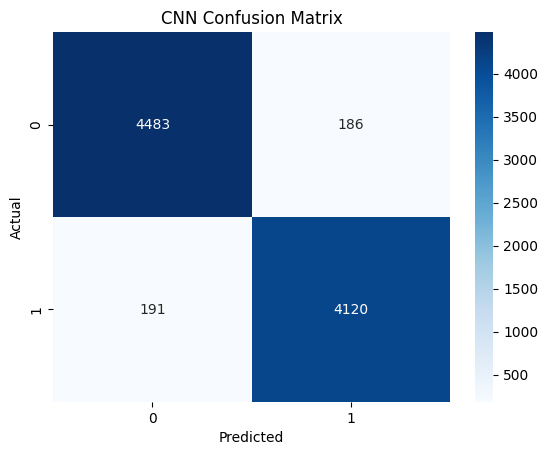

281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

GRU Evaluation:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96      4669
           1       0.96      0.96      0.96      4311

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980



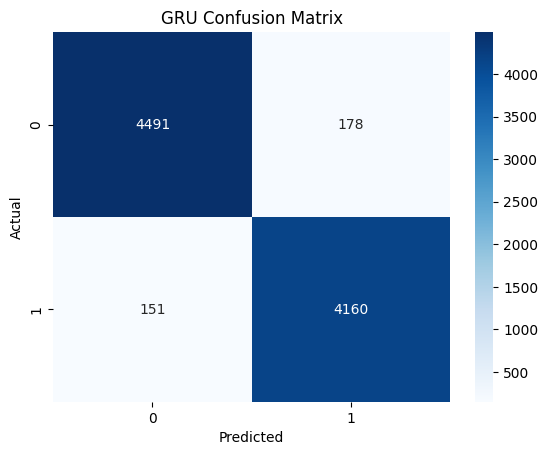

In [16]:
evaluate(bilstm_model, "BiLSTM")
evaluate(cnn_model, "CNN")
evaluate(gru_model, "GRU")

In [18]:
import gradio as gr

def predict_headline(model_name, headline):
    headline_clean = clean_text(headline)
    seq = tokenizer.texts_to_sequences([headline_clean])
    padded = pad_sequences(seq, maxlen=max_len)

    if model_name == "BiLSTM":
        pred = bilstm_model.predict(padded)[0][0]
    elif model_name == "CNN":
        pred = cnn_model.predict(padded)[0][0]
    else:  # GRU
        pred = gru_model.predict(padded)[0][0]

    label = "Real" if pred >= 0.5 else "Fake"
    confidence = round(pred if pred >= 0.5 else 1 - pred, 2)
    return f"{label} ({confidence * 100:.0f}% confidence)"

gr.Interface(
    fn=predict_headline,
    inputs=[
        gr.Dropdown(["BiLSTM", "CNN", "GRU"], label="Choose Model"),
        gr.Textbox(label="Enter News Headline")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Fake News Detector"
).launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7ae67ea1d729f6442b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
